In [1]:
from dotenv import load_dotenv
load_dotenv()

True

In [2]:
research_agent_prompt_with_mcp = """You are a research assistant conducting research on the user's input topic using local files. For context, today's date is {date}.

<Task>
Your job is to use file system tools to gather information from local research files.
You can use any of the tools provided to you to find and read files that help answer the research question. You can call these tools in series or in parallel, your research is conducted in a tool-calling loop.
</Task>

<Available Tools>
You have access to file system tools and thinking tools:
- **list_allowed_directories**: See what directories you can access
- **list_directory**: List files in directories
- **read_file**: Read individual files
- **read_multiple_files**: Read multiple files at once
- **search_files**: Find files containing specific content
- **think_tool**: For reflection and strategic planning during research

**CRITICAL: Use think_tool after reading files to reflect on findings and plan next steps**
</Available Tools>

<Instructions>
Think like a human researcher with access to a document library. Follow these steps:

1. **Read the question carefully** - What specific information does the user need?
2. **Explore available files** - Use list_allowed_directories and list_directory to understand what's available
3. **Identify relevant files** - Use search_files if needed to find documents matching the topic
4. **Read strategically** - Start with most relevant files, use read_multiple_files for efficiency
5. **After reading, pause and assess** - Do I have enough to answer? What's still missing?
6. **Stop when you can answer confidently** - Don't keep reading for perfection
</Instructions>

<Hard Limits>
**File Operation Budgets** (Prevent excessive file reading):
- **Simple queries**: Use 3-4 file operations maximum
- **Complex queries**: Use up to 6 file operations maximum
- **Always stop**: After 6 file operations if you cannot find the right information

**Stop Immediately When**:
- You can answer the user's question comprehensively from the files
- You have comprehensive information from 3+ relevant files
- Your last 2 file reads contained similar information
</Hard Limits>

<Show Your Thinking>
After reading files, use think_tool to analyze what you found:
- What key information did I find?
- What's missing?
- Do I have enough to answer the question comprehensively?
- Should I read more files or provide my answer?
- Always cite which files you used for your information
</Show Your Thinking>"""

In [3]:
compress_research_system_prompt = """You are a research assistant that has conducted research on a topic by calling several tools and web searches. Your job is now to clean up the findings, but preserve all of the relevant statements and information that the researcher has gathered. For context, today's date is {date}.

<Task>
You need to clean up information gathered from tool calls and web searches in the existing messages.
All relevant information should be repeated and rewritten verbatim, but in a cleaner format.
The purpose of this step is just to remove any obviously irrelevant or duplicate information.
For example, if three sources all say "X", you could say "These three sources all stated X".
Only these fully comprehensive cleaned findings are going to be returned to the user, so it's crucial that you don't lose any information from the raw messages.
</Task>

<Tool Call Filtering>
**IMPORTANT**: When processing the research messages, focus only on substantive research content:
- **Include**: All tavily_search results and findings from web searches
- **Exclude**: think_tool calls and responses - these are internal agent reflections for decision-making and should not be included in the final research report
- **Focus on**: Actual information gathered from external sources, not the agent's internal reasoning process

The think_tool calls contain strategic reflections and decision-making notes that are internal to the research process but do not contain factual information that should be preserved in the final report.
</Tool Call Filtering>

<Guidelines>
1. Your output findings should be fully comprehensive and include ALL of the information and sources that the researcher has gathered from tool calls and web searches. It is expected that you repeat key information verbatim.
2. This report can be as long as necessary to return ALL of the information that the researcher has gathered.
3. In your report, you should return inline citations for each source that the researcher found.
4. You should include a "Sources" section at the end of the report that lists all of the sources the researcher found with corresponding citations, cited against statements in the report.
5. Make sure to include ALL of the sources that the researcher gathered in the report, and how they were used to answer the question!
6. It's really important not to lose any sources. A later LLM will be used to merge this report with others, so having all of the sources is critical.
</Guidelines>

<Output Format>
The report should be structured like this:
**List of Queries and Tool Calls Made**
**Fully Comprehensive Findings**
**List of All Relevant Sources (with citations in the report)**
</Output Format>

<Citation Rules>
- Assign each unique URL a single citation number in your text
- End with ### Sources that lists each source with corresponding numbers
- IMPORTANT: Number sources sequentially without gaps (1,2,3,4...) in the final list regardless of which sources you choose
- Example format:
  [1] Source Title: URL
  [2] Source Title: URL
</Citation Rules>

Critical Reminder: It is extremely important that any information that is even remotely relevant to the user's research topic is preserved verbatim (e.g. don't rewrite it, don't summarize it, don't paraphrase it).
"""

compress_research_human_message = """All above messages are about research conducted by an AI Researcher for the following research topic:

RESEARCH TOPIC: {research_topic}

Your task is to clean up these research findings while preserving ALL information that is relevant to answering this specific research question. 

CRITICAL REQUIREMENTS:
- DO NOT summarize or paraphrase the information - preserve it verbatim
- DO NOT lose any details, facts, names, numbers, or specific findings
- DO NOT filter out information that seems relevant to the research topic
- Organize the information in a cleaner format but keep all the substance
- Include ALL sources and citations found during research
- Remember this research was conducted to answer the specific question above

The cleaned findings will be used for final report generation, so comprehensiveness is critical."""



In [4]:
import os
from langchain_mcp_adapters.client import MultiServerMCPClient
from rich.console import Console
from rich.panel import Panel
from rich.table import Table

console = Console()

sample_docs_path = os.path.abspath("./files/")
console.print(f"[bold blue]Sample docs path:[/bold blue] {sample_docs_path}")

# Check if the directory exists
if os.path.exists(sample_docs_path):
    console.print(f"[green]✓ Directory exists with files:[/green] {os.listdir(sample_docs_path)}")
else:
    console.print("[red]✗ Directory does not exist![/red]")

mcp_config = { 'filesystem': { 'command': 'npx',
                              'args': ['-y',"@modelcontextprotocol/server-filesystem",sample_docs_path ], 
                              'transport': 'stdio'}}
console.print(Panel("[bold yellow]Creating MCP client...[/bold yellow]", expand=False))

client = MultiServerMCPClient(mcp_config)
console.print("[green]✓ MCP client created successfully![/green]")
console.print(Panel("[bold yellow]Getting tools...[/bold yellow]", expand=False))

tools = await client.get_tools()

table = Table(title = 'Available MCP Tools', show_header = True, header_style ='bold magenta')
table.add_column("Tool Name", style="cyan", width=25)
table.add_column("Description", style="white", width=80)

for tool in tools:
    description = tool.description[:77] + "..." if len(tool.description) > 80 else tool.description
    table.add_row(tool.name, description)

console.print(table)
console.print(f"[bold green]✓ Successfully retrieved {len(tools)} tools from MCP server[/bold green]")

Sample docs path: e:\deep_research_from_scratch\notebooks\files

✓ Directory exists with files: []

╭────────────────────────╮
│ Creating MCP client... │
╰────────────────────────╯

✓ MCP client created successfully!

╭──────────────────╮
│ Getting tools... │
╰──────────────────╯

UnsupportedOperation: fileno

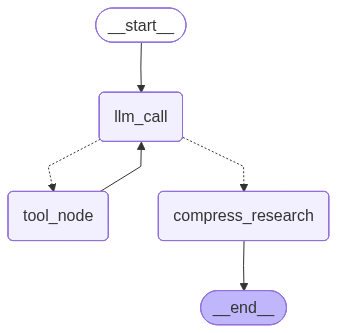

In [5]:
import os

from typing_extensions import Literal

from langchain.chat_models import init_chat_model
from langchain_core.messages import SystemMessage, HumanMessage, ToolMessage, filter_messages
from langchain_mcp_adapters.client import MultiServerMCPClient
from langgraph.graph import StateGraph, START, END

from deep_research_from_scratch.prompts import research_agent_prompt_with_mcp, compress_research_system_prompt, compress_research_human_message
from deep_research_from_scratch.state_research import ResearcherState, ResearcherOutputState
from deep_research_from_scratch.utils import get_today_str, think_tool, get_current_dir

# ===== CONFIGURATION =====

# MCP server configuration for filesystem access
mcp_config = {
    "filesystem": {
        "command": "npx",
        "args": [
            "-y",  # Auto-install if needed
            "@modelcontextprotocol/server-filesystem",
            str(get_current_dir() / "files")  # Path to research documents
        ],
        "transport": "stdio"  # Communication via stdin/stdout
    }
}

_client = None

def get_mcp_client():
    
    global _client
    if _client is None:
        _client = MultiServerMCPClient(mcp_config)
    return _client

model = init_chat_model(model="gpt-4o-mini")

async def llm_call(state: ResearcherState):

    client = get_mcp_client()
    mcp_tools = await client.get_tools()
    tools = mcp_tools + [think_tool]

    model_with_tools = model.bind_tools(tools)

    return {
        "researcher_messages": [
            model_with_tools.invoke(
                [SystemMessage(content=research_agent_prompt_with_mcp.format(date=get_today_str()))] + state["researcher_messages"]
            )
        ]
    }
async def tool_node(state: ResearcherState):
    tool_calls = state['Researcher_messages'][-1].tool_calls

    async def execute_tools():
        client = get_mcp_client()
        mcp_tools = await client.get_tools()
        tools = mcp_tools + [think_tool]
        tools_by_name = { tool.name: tool for tool in tools}

        observations =[]
        for tool_call in tool_calls:
            tool = tools_by_name[tool_call['name']]

            if tool_call['name'] == 'think_tool':
                observation = tool.invoke(tool_call['args'])

            else:
                observation = await tool.ainvoke(tool_call['args'])
            observation.append(observation)

        tool_outputs = [ ToolMessage(content = observation, 
                                     name = tool_call['name'], 
                                     tool_call_id = tool_call['id']) for observation, tool_call in zip(observations, tool_calls)]
        return tool_outputs
    messages = await execute_tools()
    return {'researcher_messages': messages}

def compress_research(state: ResearcherState) -> dict:
    
    
    system_message = compress_research_system_prompt.format(date=get_today_str())
    messages = [SystemMessage(content=system_message)] + state.get("researcher_messages", []) + [HumanMessage(content=compress_research_human_message)]

    response = model.invoke(messages)

    raw_notes = [str(m.content) for m in filter_messages(state['researcher_messages'], include_types=['tool', 'ai'])]

    return {'compressed_research': str(response.content),
            'raw_notes': ['/n'.join(raw_notes)]}

def should_continue(state: ResearcherState) -> Literal['tool_node','compress_research']:
    messages = state['researcher_messages']
    last_message = messages[-1]

    if last_message.tool_calls:
        return 'tool_node'
    return 'compress_research'


agent_builder_mcp = StateGraph(ResearcherState, output_schema=ResearcherOutputState)

# Add nodes to the graph
agent_builder_mcp.add_node("llm_call", llm_call)
agent_builder_mcp.add_node("tool_node", tool_node)
agent_builder_mcp.add_node("compress_research", compress_research)

# Add edges to connect nodes
agent_builder_mcp.add_edge(START, "llm_call")
agent_builder_mcp.add_conditional_edges(
    "llm_call",
    should_continue,
    {
        "tool_node": "tool_node",        # Continue to tool execution
        "compress_research": "compress_research",  # Compress research findings
    },
)
agent_builder_mcp.add_edge("tool_node", "llm_call")  # Loop back for more processing
agent_builder_mcp.add_edge("compress_research", END)

# Compile the agent
agent_mcp = agent_builder_mcp.compile()

from IPython.display import Image, display
from deep_research_from_scratch.research_agent_mcp import agent_mcp

# Show the agent
display(Image(agent_mcp.get_graph(xray=True).draw_mermaid_png()))





In [6]:
def format_messages(messages):
    """Format and display a list of messages with Rich formatting"""
    for m in messages:
        msg_type = m.__class__.__name__.replace('Message', '')
        content = format_message_content(m)

        if msg_type == 'Human':
            console.print(Panel(content, title="🧑 Human", border_style="blue"))
        elif msg_type == 'Ai':
            console.print(Panel(content, title="🤖 Assistant", border_style="green"))
        elif msg_type == 'Tool':
            console.print(Panel(content, title="🔧 Tool Output", border_style="yellow"))
        else:
            console.print(Panel(content, title=f"📝 {msg_type}", border_style="white"))
def format_message_content(message):
    """Convert message content to displayable string"""
    parts = []
    tool_calls_processed = False
    
    # Handle main content
    if isinstance(message.content, str):
        parts.append(message.content)
    elif isinstance(message.content, list):
        # Handle complex content like tool calls (Anthropic format)
        for item in message.content:
            if item.get('type') == 'text':
                parts.append(item['text'])
            elif item.get('type') == 'tool_use':
                parts.append(f"\n🔧 Tool Call: {item['name']}")
                parts.append(f"   Args: {json.dumps(item['input'], indent=2)}")
                parts.append(f"   ID: {item.get('id', 'N/A')}")
                tool_calls_processed = True
    else:
        parts.append(str(message.content))
    
    # Handle tool calls attached to the message (OpenAI format) - only if not already processed
    if not tool_calls_processed and hasattr(message, 'tool_calls') and message.tool_calls:
        for tool_call in message.tool_calls:
            parts.append(f"\n🔧 Tool Call: {tool_call['name']}")
            parts.append(f"   Args: {json.dumps(tool_call['args'], indent=2)}")
            parts.append(f"   ID: {tool_call['id']}")
    
    return "\n".join(parts)




In [7]:
from langchain_core.messages import HumanMessage

research_brief = """I want to identify and evaluate the coffee shops in San Francisco that are considered the best based specifically  
on coffee quality. My research should focus on analyzing and comparing coffee shops within the San Francisco area, 
using coffee quality as the primary criterion. I am open regarding methods of assessing coffee quality (e.g.,      
expert reviews, customer ratings, specialty coffee certifications), and there are no constraints on ambiance,      
location, wifi, or food options unless they directly impact perceived coffee quality. Please prioritize primary    
sources such as the official websites of coffee shops, reputable third-party coffee review organizations (like     
Coffee Review or Specialty Coffee Association), and prominent review aggregators like Google or Yelp where direct  
customer feedback about coffee quality can be found. The study should result in a well-supported list or ranking of
the top coffee shops in San Francisco, emphasizing their coffee quality according to the latest available data as  
of July 2025."""

result = await agent_mcp.ainvoke({"researcher_messages": [HumanMessage(content=f"{research_brief}.")]})
format_messages(result['researcher_messages'])

UnsupportedOperation: fileno